In [1]:
import torch
import dnois
from dnois.optics import rt

In [2]:
_ = torch.set_grad_enabled(False)
torch.set_printoptions(precision=12)
torch.set_default_dtype(torch.double)

dnois.conf.DETECTION_RADIUS_EPS = 1e-3
dnois.set_default('length', 'mm')
dnois.float_print_fmt = '.12g'


In [3]:
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# dev = 'cpu'

In [ ]:
sq = rt.CoaxialSurfaceSequence([
    # 表面0: 主镜 (Primary Mirror)
    rt.Conic(
        -1.227200000000000E+002,      # 第1行: Radius of curvature (曲率半径) = -122.72 mm
        -0.900000000000000E+000,      # 第2行: Conic constant (圆锥常数) = -1.0 (抛物面)  
        'vacuum',      # 第3行: Material (材料) = 真空
        1.100000000000000E+001,       # 第4行: Aperture radius (孔径半径) = 11.0 mm 
        True,  # 第5行: Reflective (反射面标志) = True
        rt.IntersectionConfig(use_analytical=False),         # 第6行: 交点计算配置 
        d=-3.375000000000000E+001      # 第7行: Distance to next surface (到下一表面距离) = -33.75 mm 
    ),
    
    # 表面1: 次镜 (Secondary Mirror) - Zernike面
    rt.Zernike(
        -1.429400000000000E+002,      # 第1行: Radius of curvature (曲率半径) = -142.94 mm
        0.000000000000000E+000,       # 第2行: Conic constant (圆锥常数) = 0.0 (球面)  
        [0],           # 第3行: Zernike indices (Zernike项索引)
        [0.014],           # 第4行: Zernike coefficients (Zernike系数) = 0.014
        6.340000000000000E+000,       # 第5行: Aperture radius (孔径半径) = 6.34 mm  
        'vacuum',      # 第6行: Material (材料) = 真空
        1.000000000000000E+001,       # 第7行: Semi-diameter (半径) = 10.0 mm  
        True,          # 第8行: Reflective (反射面标志) = True
        d=4.499100000000000E+001      # 第9行: Distance to next surface (到下一表面距离) = 44.991 mm
    ),
], stop_idx=0)  # 光阑在表面0 (主镜处)

In [5]:
print("=== 卡塞格林系统焦距计算 ===")

# 主镜参数
R1 = -1.227200000000000E+002  # 主镜曲率半径 (mm)
f1 = R1 / 2    # 主镜焦距 (抛物面镜：f = R/2)
print(f"主镜曲率半径 R1: {R1:.3f} mm")
print(f"主镜焦距 f1: {f1:.3f} mm")

# 次镜参数  
R2 = -142.940  # 次镜曲率半径 (mm)
f2 = R2 / 2    # 次镜焦距 (球面近似)
print(f"次镜曲率半径 R2: {R2:.3f} mm")
print(f"次镜焦距 f2: {f2:.3f} mm")

# 镜间距离
d = 33.750 + 44.991  # 主镜到次镜 + 次镜到像面
print(f"系统总长度: {d:.3f} mm")

# 卡塞格林系统的有效焦距估算
# 对于卡塞格林系统：EFL ≈ f1 * M，其中M是放大率
M = abs(f2) / (abs(f2) - 33.750)  # 放大率估算
EFL = abs(f1) * M  # 有效焦距

# 根据入瞳直径和F数关系验证
entrance_pupil_diameter = 22.00  # mm
F_number = EFL / entrance_pupil_diameter
print(f"F数: F/{F_number:.1f}")

# 设定perspective_focal_length
perspective_focal_length = EFL
print(f"\n✓ 建议的perspective_focal_length: {perspective_focal_length:.1f} mm")


=== 卡塞格林系统焦距计算 ===
主镜曲率半径 R1: -122.720 mm
主镜焦距 f1: -61.360 mm
次镜曲率半径 R2: -142.940 mm
次镜焦距 f2: -71.470 mm
系统总长度: 78.741 mm
F数: F/5.3

✓ 建议的perspective_focal_length: 116.3 mm


In [6]:
sensor = dnois.sensor.StandardSensor(1000, 3e-3)

In [7]:
optics = rt.CoaxialRayTracing(
    sq,
    sensor,
    perspective_focal_length= 116.3,  
    sampler=sq.first.aperture.sampler('rect', 512),  # 使用.first在光阑处采样
    wl=[1.064e-3],  # 波长1064nm
    depth=float('inf'),
)

camera = dnois.Camera(optics, sensor)
camera.double()
camera.to(device=dev)


Camera(
  (optics): CoaxialRayTracing(
    (conv_formation): Simple()
    (surfaces): CoaxialSurfaceSequence(
      (0): Conic(
        material=vacuum, reflective=True,
        roc=-122.72mm,
        conic=-0.9
        (aperture): CircularAperture(radius=11mm)
        (context): CoaxialContext(distance=-33.75mm)
      )
      (1): Zernike(
        material=vacuum, reflective=True,
        roc=-142.94mm,
        conic=0,
        a1=0,
        z1=0.014
        (aperture): CircularAperture(radius=10mm)
        (context): CoaxialContext(distance=44.991mm)
      )
    )
  )
  (sensor): StandardSensor(
    resolution=(1000, 1000), pixel_size=(0.003mm, 0.003mm),
    rgb=True, bayer_pattern=None, noise_std=0.0, max_value=1.0, quantize=256 (differentiable=True), linear2srgb=True
  )
)

In [8]:
# 1. width参数：点列图显示范围
pixel_size = 3e-3  # 像元尺寸 (mm)
airy_disk_radius = 1.22 * 1.064e-3 * F_number  # 艾里斑半径
print(airy_disk_radius)
# 设置width为艾里斑直径的几倍，确保能看到主要的像差
# width_suggestion = max(8 * airy_disk_radius, 20 * pixel_size)  # 取较大值
width_suggestion = 200e-3

# 2. entr_d参数：入瞳直径
actual_entr_d = 2 * sq[0].aperture.radius.item()  # 系统实际入瞳直径

spot_width = width_suggestion
spot_entr_d = actual_entr_d
spot_entr_z = 0.0


0.006859875389877567


In [9]:
resolution = 1000  # 1000x1000 像素
pixel_size_mm = 3e-3  # 像元尺寸：5 μm = 0.005 mm
pixel_size_um = pixel_size_mm * 1000  # 转换为微米

print(f"传感器分辨率: {resolution} × {resolution} 像素")
print(f"像元尺寸: {pixel_size_um:.3f} μm ({pixel_size_mm:.6f} mm)")

# 传感器总尺寸
sensor_size_mm = resolution * pixel_size_mm
sensor_size_um = sensor_size_mm * 1000

# 像元尺寸应该小于艾里斑半径的1/2，以满足奈奎斯特采样
if 'airy_disk_radius' in globals():
    airy_radius_um = airy_disk_radius * 1000
    nyquist_pixel_size = airy_radius_um / 2
    print(f"艾里斑半径: {airy_radius_um:.2f} μm")
    print(f"奈奎斯特采样要求像元尺寸 < {nyquist_pixel_size:.2f} μm")
    
    if pixel_size_um < nyquist_pixel_size:
        print(f"✓ 当前像元尺寸 {pixel_size_um:.3f} μm 满足奈奎斯特采样要求")
    else:
        print(f"⚠ 当前像元尺寸 {pixel_size_um:.3f} μm 可能导致欠采样")

sensor = dnois.sensor.StandardSensor(resolution, pixel_size_mm)
print(f"\n✓ 传感器创建完成: {resolution}×{resolution}, {pixel_size_um:.3f}μm像元")

传感器分辨率: 1000 × 1000 像素
像元尺寸: 3.000 μm (0.003000 mm)
艾里斑半径: 6.86 μm
奈奎斯特采样要求像元尺寸 < 3.43 μm
✓ 当前像元尺寸 3.000 μm 满足奈奎斯特采样要求

✓ 传感器创建完成: 1000×1000, 3.000μm像元


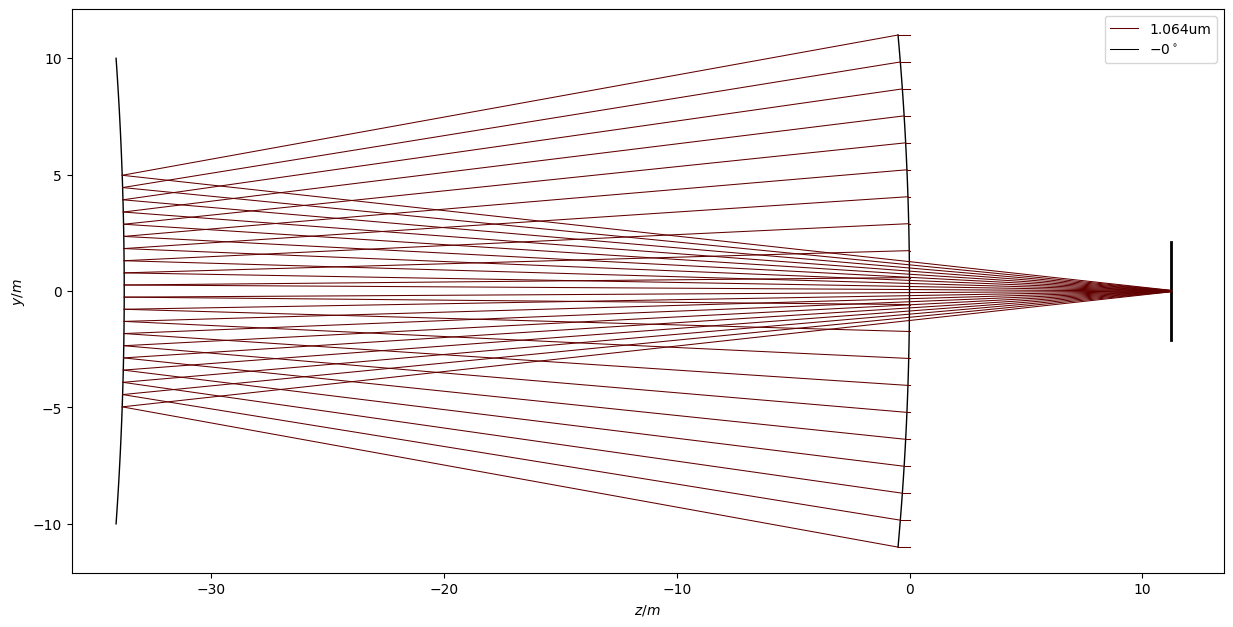

In [10]:
# 绘制光路截面图
fig = optics.plot_cross_section(height=optics.new_tensor([0]).deg2rad().tan(), wl=1.064e-3, init_rays=20)


RMS=tensor([0.017952018921, 0.022325217291, 0.026580871429])
geo radius=tensor([0.031230011573, 0.058464991774, 0.063161899954])


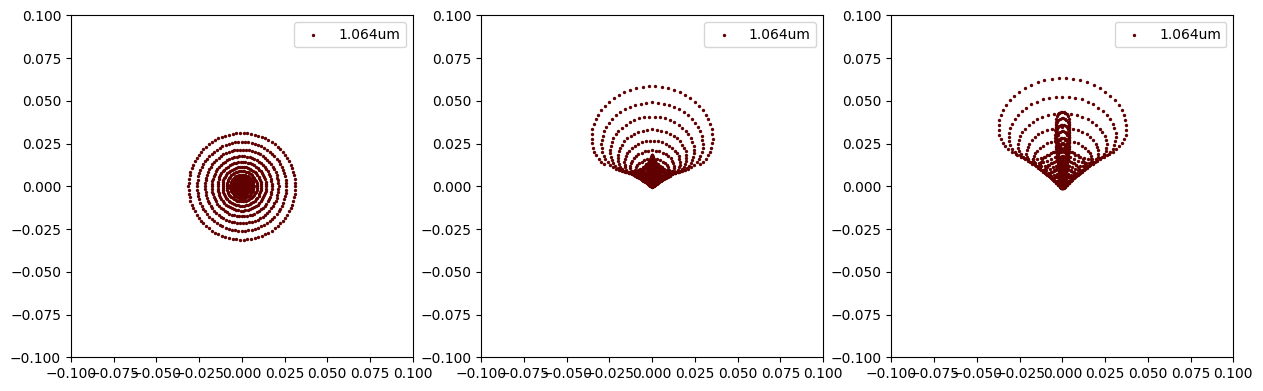

In [11]:
td = 15
obj = optics.fovd2obj(optics.new_tensor([(0., 0.), (0., 1.41), (0., 2)]).deg2rad(), float('inf'))
spot_diagram = optics.plot_spot_diagram(obj, 1.064e-3, ray_density=td, width=200e-3, entr_d=22.00, entr_z=0.)
print(f'RMS={spot_diagram.rms}')
print(f'geo radius={spot_diagram.geo_radius}')

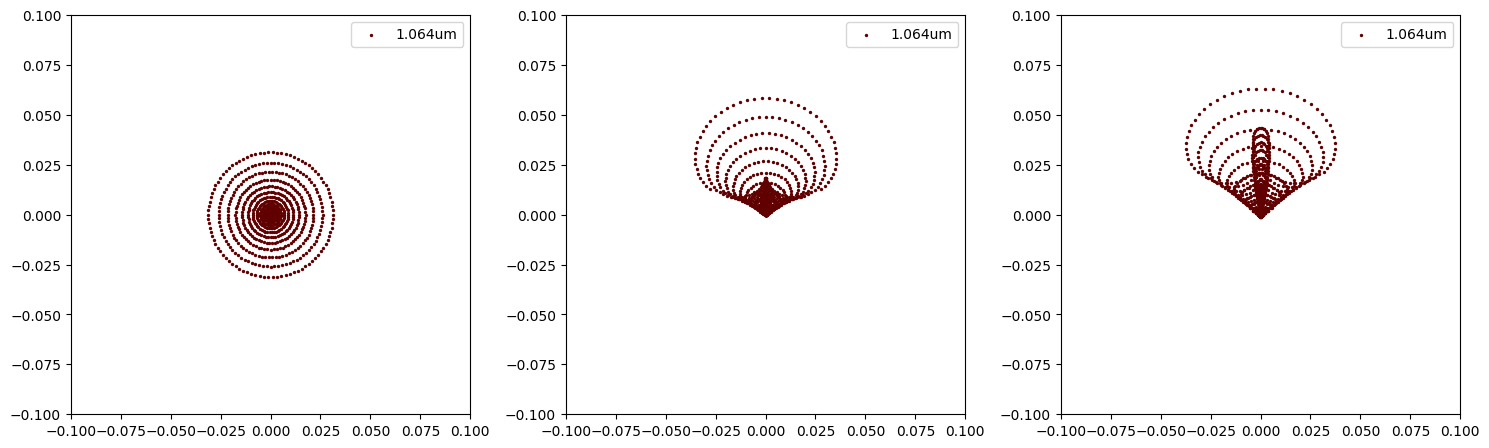

RMS=tensor([17.952018921044, 22.325217290978, 26.580871429101]) μm
geo radius=tensor([31.230011572506, 58.464991773907, 63.161899953721]) μm


In [12]:
import matplotlib.pyplot as plt
td = 15
obj = optics.fovd2obj(optics.new_tensor([(0., 0.), (0., 1.41), (0., 2)]).deg2rad(), float('inf'))
spot_diagram = optics.plot_spot_diagram(obj, 1.064e-3, ray_density=td, width=200e-3, entr_d=22.00, entr_z=0.)
plt.tight_layout()
plt.show()

# 转换为微米单位显示
rms_um = spot_diagram.rms * 1000
geo_radius_um = spot_diagram.geo_radius * 1000

print(f'RMS={rms_um} μm')
print(f'geo radius={geo_radius_um} μm')



In [13]:
optics.psf_model.psf_center=rt.MeanPsfCenter()

In [14]:
psf=optics.psf(obj)
psf.shape

torch.Size([3, 1, 64, 64])

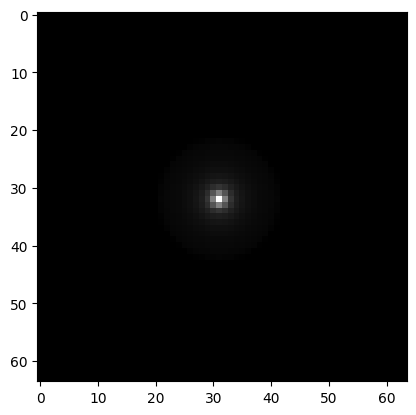

In [15]:
import matplotlib.pyplot as plt
plt.imshow(psf[0,0].cpu().detach().numpy(),cmap='gray')

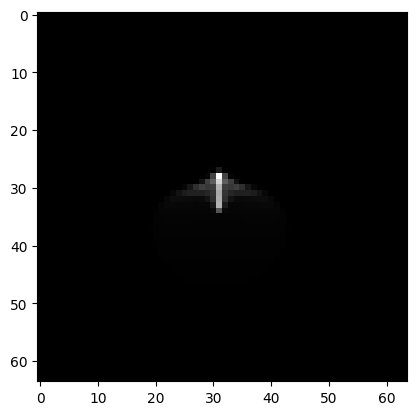

In [16]:
plt.imshow(psf[1,0].cpu().detach().numpy(),cmap='gray')


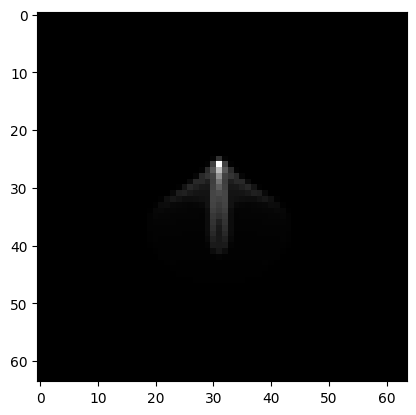

In [17]:
plt.imshow(psf[2,0].cpu().detach().numpy(),cmap='gray')